In [3]:
from google.colab import files
uploaded = files.upload()

Saving Wrapping.png to Wrapping.png


Image loaded successfully!
Original Image


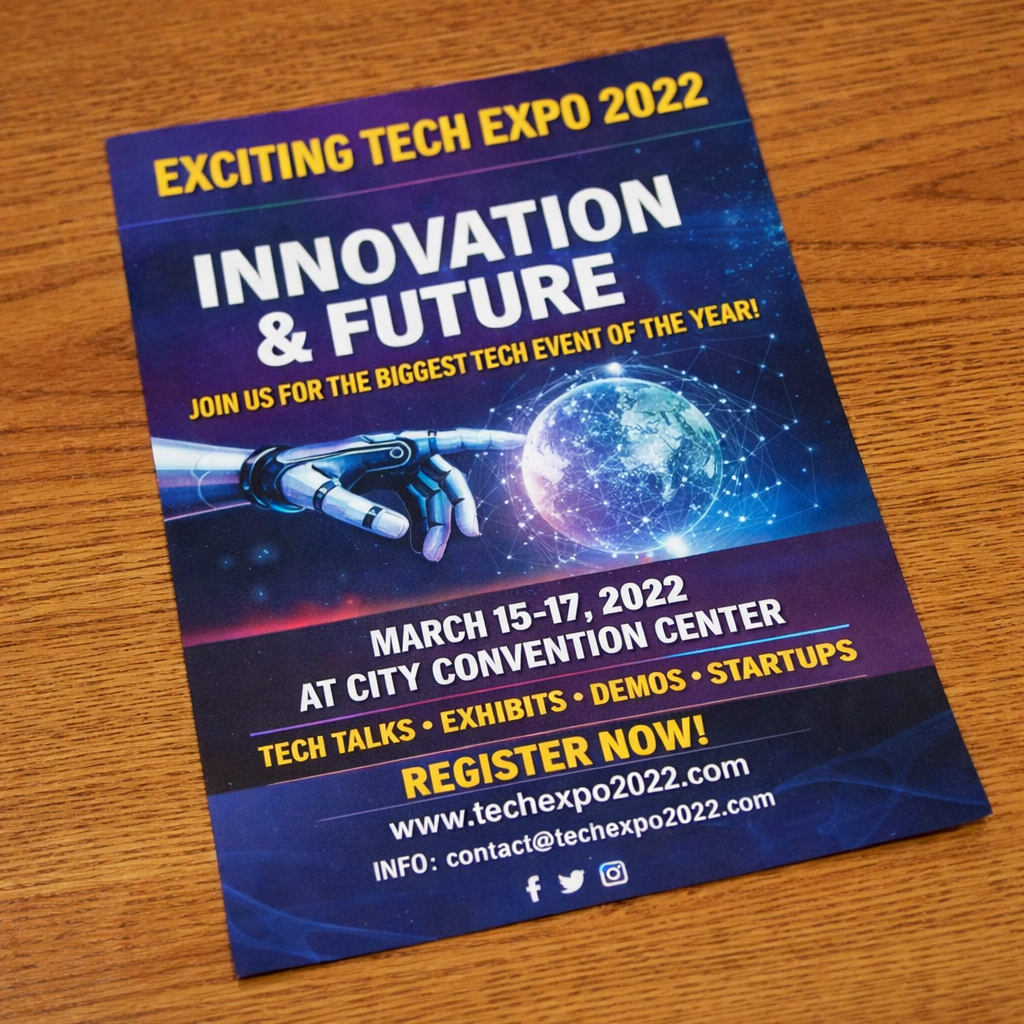

Warped Image (Corrected Perspective)


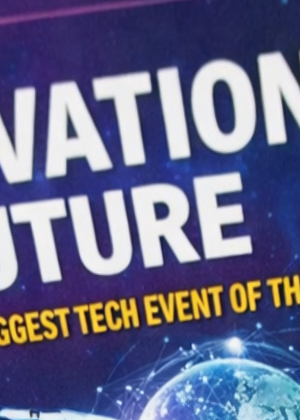

In [5]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# -------- 1. Load Image --------
image_path = "/content/Wrapping.png"
img = cv2.imread(image_path)

# Check if image loaded
if img is None:
    print("Error: Image not found. Check the file name.")
else:
    print("Image loaded successfully!")

# Show original image
print("Original Image")
cv2_imshow(img)


# -------- 2. Define Source Points --------
# Points from the tilted document in the image
src_points = np.array([
    [420, 170],   # top-left
    [650, 150],   # top-right
    [680, 420],   # bottom-right
    [400, 440]    # bottom-left
], dtype="float32")


# -------- 3. Define Destination Points --------
# Output size (A4-like rectangle)
width = 300
height = 420

dst_points = np.array([
    [0, 0],
    [width, 0],
    [width, height],
    [0, height]
], dtype="float32")


# -------- 4. Compute Perspective Transform --------
matrix = cv2.getPerspectiveTransform(src_points, dst_points)


# -------- 5. Apply Warping --------
warped_image = cv2.warpPerspective(img, matrix, (width, height))


# -------- 6. Show Result --------
print("Warped Image (Corrected Perspective)")
cv2_imshow(warped_image)